**K-means.**
Разбивает данные на K заранее заданных кластеров, итеративно перемещая центры кластеров (центроиды) к центрам масс ближайших точек. Минус: нужно заранее знать число кластеров; плюс: работает очень быстро.

**DBSCAN.**
Группирует точки, находящиеся близко друг к другу (в радиусе eps), и автоматически отбрасывает одиночные точки как шум. Плюс: не требует указывать число кластеров и находит группы произвольной формы; минус: чувствителен к выбору радиуса.

**Mean Shift.**
"Сдвигает" каждую точку к ближайшему пику плотности распределения данных и объединяет точки, пришедшие к одному пику. Плюс: сам определяет число кластеров; минус: медленный на больших объемах данных.

## Используемые библиотеки

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

## Используемый датасет

In [48]:
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"\nДатасет Iris содержит {X.shape[0]} образцов и {X.shape[1]} признака.")
print(f"Признаки: {feature_names}")
print(f"Целевые классы: {target_names} (0: {target_names[0]}, 1: {target_names[1]}, 2: {target_names[2]})")

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y_true
df['target_name'] = df['target'].map({0: target_names[0], 1: target_names[1], 2: target_names[2]})

print("\nПервые 10 строк датасета:")
print(df.head(10))

print("\nСтатистическое описание признаков:")
print(df[feature_names].describe().round(2))


Датасет Iris содержит 150 образцов и 4 признака.
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Целевые классы: ['setosa' 'versicolor' 'virginica'] (0: setosa, 1: versicolor, 2: virginica)

Первые 10 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4      

## Обработка датасета

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Тепловая карта

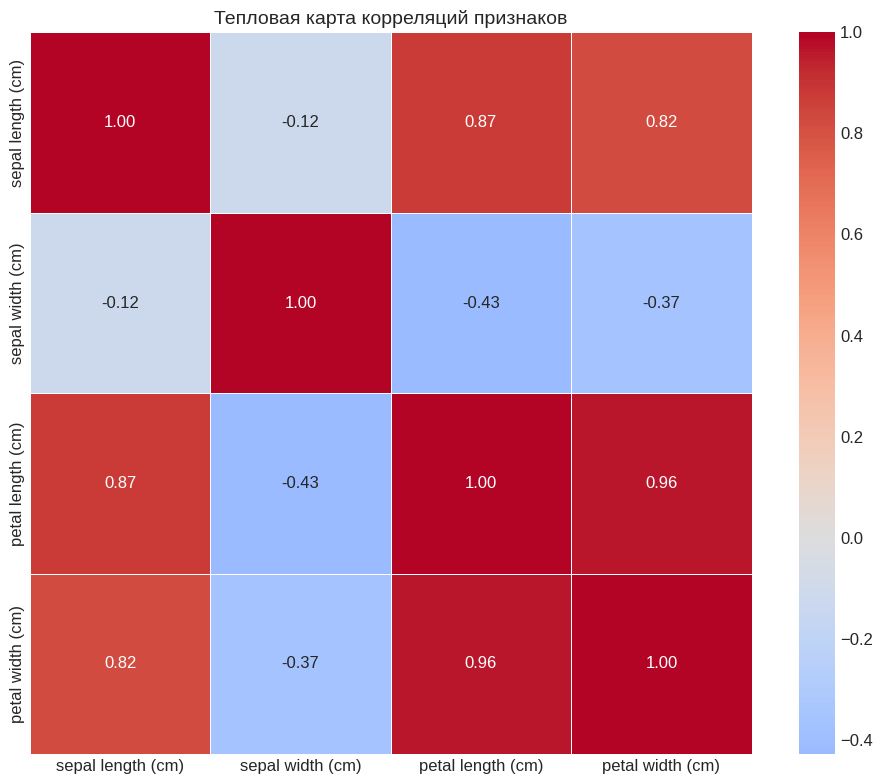

In [50]:
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)

plt.figure(figsize=(10, 8))
correlation_matrix = df_scaled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Тепловая карта корреляций признаков', fontsize=14)
plt.tight_layout()
plt.show()

## Обучение моделей

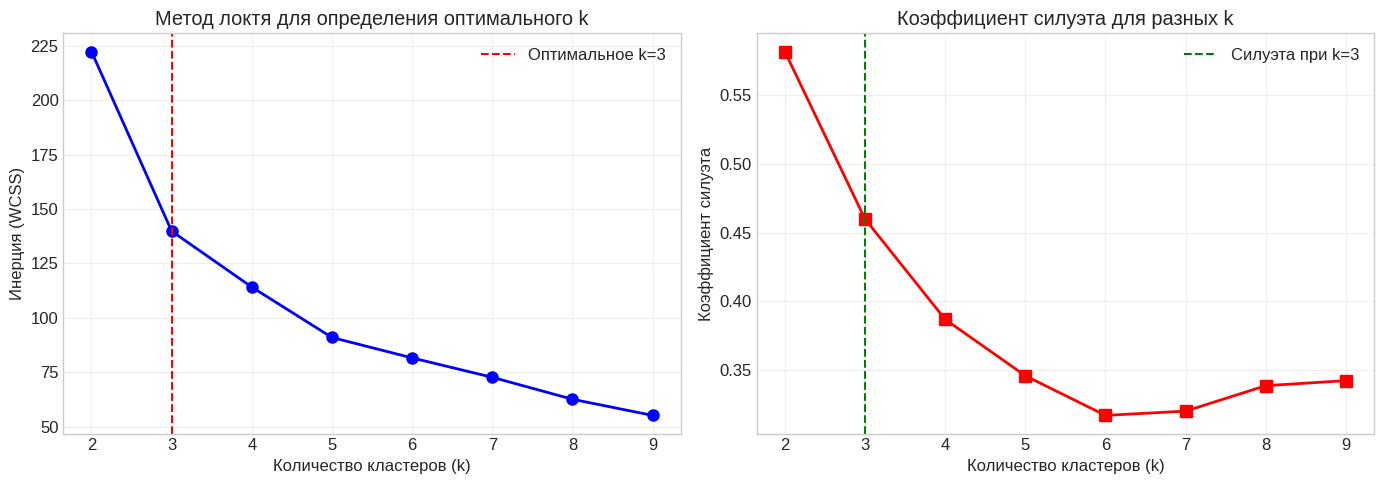

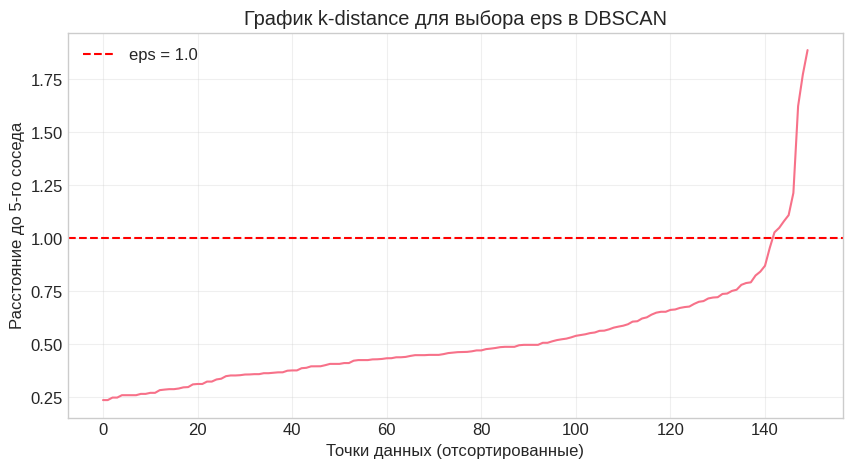

In [51]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', label='Оптимальное k=3')
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].set_title('Метод локтя для определения оптимального k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='green', linestyle='--', label='Силуэта при k=3')
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Коэффициент силуэта')
axes[1].set_title('Коэффициент силуэта для разных k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('График k-distance для выбора eps в DBSCAN')
plt.axhline(y=1.0, color='red', linestyle='--', label='eps = 1.0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=100)
mean_shift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
mean_shift_labels = mean_shift.fit_predict(X_scaled)


## Прогнозы моделей


Метрики качества кластеризации:
     Метод  Кластеры  Шум  Силуэт   ARI   NMI
   k-means         3    0   0.460 0.620 0.659
    DBSCAN         3    3   0.538 0.554 0.696
Mean Shift         3    0   0.425 0.561 0.703


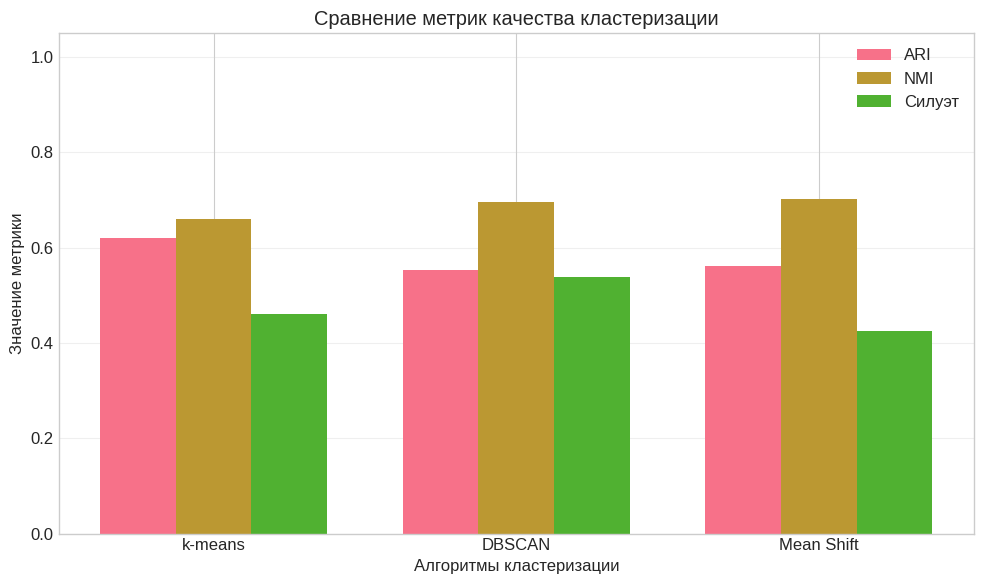

In [52]:
def evaluate_clustering(labels, true_labels, name):
    n_clusters = len(np.unique(labels))
    if n_clusters > 1 :
        sil_score = silhouette_score(X_scaled, labels)
    else:
        sil_score = -1

    ari = adjusted_rand_score(true_labels, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)

    return {
        'Метод': name,
        'Кластеры': n_clusters,
        'Шум': np.sum(labels == -1) if -1 in labels else 0,
        'Силуэт': sil_score,
        'ARI': ari,
        'NMI': nmi
    }

results = []
results.append(evaluate_clustering(kmeans_labels, y_true, 'k-means'))
results.append(evaluate_clustering(dbscan_labels, y_true, 'DBSCAN'))
results.append(evaluate_clustering(mean_shift_labels, y_true, 'Mean Shift'))

results_df = pd.DataFrame(results)
print("\nМетрики качества кластеризации:")
print(results_df.to_string(index=False, float_format='%.3f'))

metrics_to_plot = ['ARI', 'NMI', 'Силуэт']
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [r[metric] for r in results]
    ax.bar(x + i*width, values, width, label=metric)

ax.set_xlabel('Алгоритмы кластеризации')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик качества кластеризации')
ax.set_xticks(x + width)
ax.set_xticklabels([r['Метод'] for r in results])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Графики выходных результатов

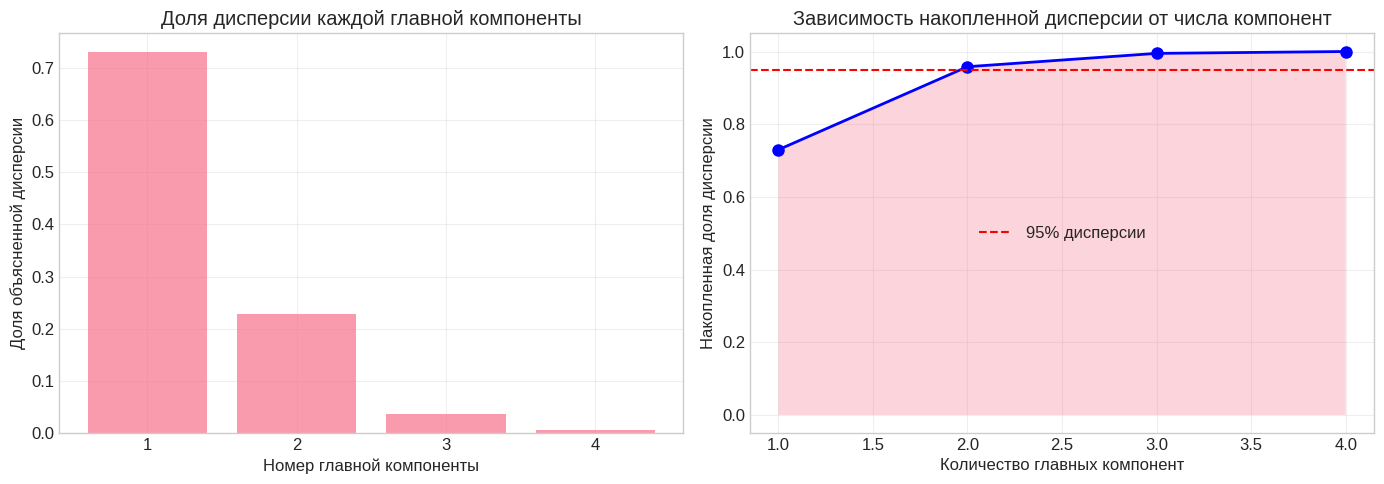

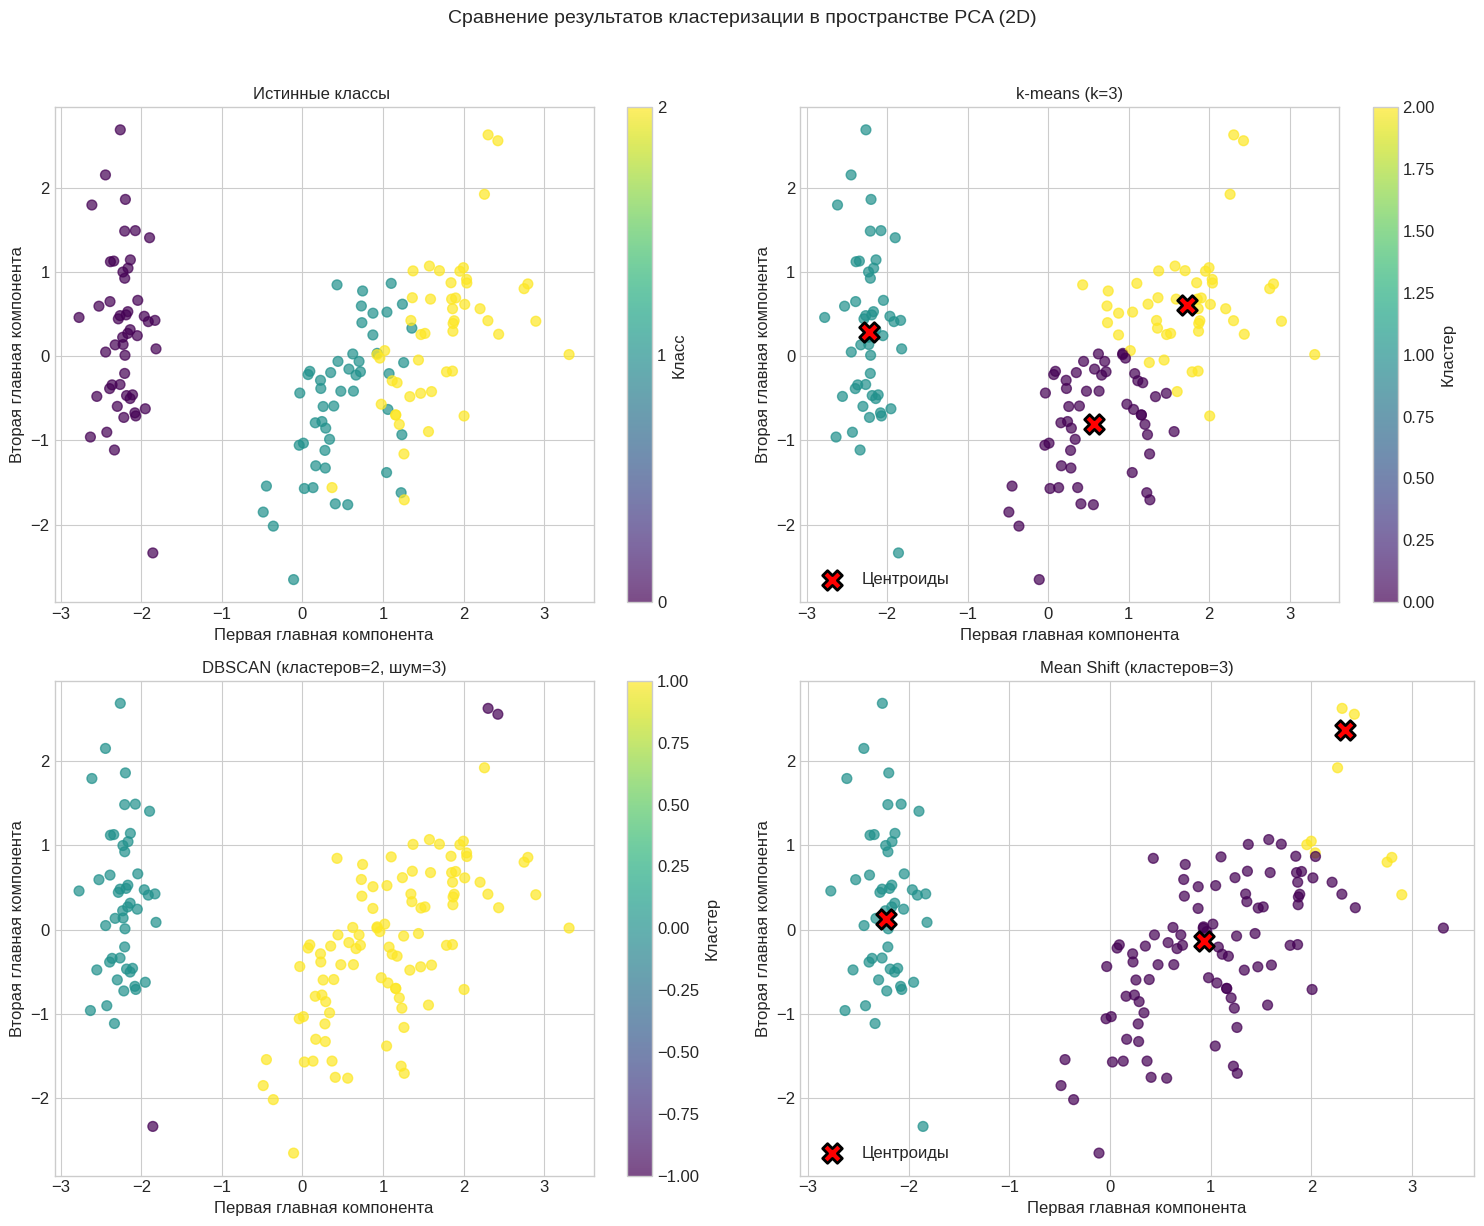

In [53]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, label='Индивидуальная')
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Доля объясненной дисперсии')
axes[0].set_title('Доля дисперсии каждой главной компоненты')
axes[0].set_xticks(range(1, len(explained_variance_ratio) + 1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% дисперсии')
axes[1].fill_between(range(1, len(cumulative_variance) + 1), cumulative_variance, alpha=0.3)
axes[1].set_xlabel('Количество главных компонент')
axes[1].set_ylabel('Накопленная доля дисперсии')
axes[1].set_title('Зависимость накопленной дисперсии от числа компонент')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7)
axes[0, 0].set_title('Истинные классы ', fontsize=12)
axes[0, 0].set_xlabel('Первая главная компонента')
axes[0, 0].set_ylabel('Вторая главная компонента')
plt.colorbar(scatter1, ax=axes[0, 0], ticks=[0, 1, 2], label='Класс')

scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)
axes[0, 1].scatter(pca_2d.transform(kmeans.cluster_centers_)[:, 0],
                   pca_2d.transform(kmeans.cluster_centers_)[:, 1],
                   c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Центроиды')
axes[0, 1].set_title(f'k-means (k={len(np.unique(kmeans_labels))})', fontsize=12)
axes[0, 1].set_xlabel('Первая главная компонента')
axes[0, 1].set_ylabel('Вторая главная компонента')
axes[0, 1].legend()
plt.colorbar(scatter2, ax=axes[0, 1], label='Кластер')

scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', s=50, alpha=0.7)
axes[1, 0].set_title(f'DBSCAN (кластеров={len(np.unique(dbscan_labels[dbscan_labels!=-1]))}, шум={np.sum(dbscan_labels==-1)})', fontsize=12)
axes[1, 0].set_xlabel('Первая главная компонента')
axes[1, 0].set_ylabel('Вторая главная компонента')
plt.colorbar(scatter3, ax=axes[1, 0], label='Кластер')

scatter4 = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=mean_shift_labels, cmap='viridis', s=50, alpha=0.7)
axes[1, 1].scatter(pca_2d.transform(mean_shift.cluster_centers_)[:, 0],
                   pca_2d.transform(mean_shift.cluster_centers_)[:, 1],
                   c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Центроиды')
axes[1, 1].set_title(f'Mean Shift (кластеров={len(np.unique(mean_shift_labels))})', fontsize=12)
axes[1, 1].set_xlabel('Первая главная компонента')
axes[1, 1].set_ylabel('Вторая главная компонента')
axes[1, 1].legend()

plt.suptitle('Сравнение результатов кластеризации в пространстве PCA (2D)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()